In [189]:
import pickle
import pandas as pd
import numpy as np
import operator
from numba import njit

In [190]:
ot = pd.read_pickle("pickles/sept.pickle")
nt = pd.read_pickle("pickles/tisch.pickle")
bible = pd.concat([ot, nt], axis=0)
strongs = pd.read_pickle("pickles/strongs.pickle")

In [191]:
with open('references-naive.pickle', 'rb') as f:
    found = pickle.load(f)

found = sorted(found, key=operator.itemgetter(0))

# quote start, quote end, source start, source end
found = [((nloc, nloc+nlen), (oloc, oloc+olen)) for nloc, nlen, oloc, olen in found]

In [192]:
@njit
def locs_overlap(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return s1 <= s2 <= e1 or s2 <= s1 <= e2


@njit
def refs_overlap(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return locs_overlap(nloc1, nloc2) and locs_overlap(oloc1, oloc2)


@njit
def merge_locs(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return min(s1, s2), max(e1, e2)


@njit
def merge_refs(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return merge_locs(nloc1, nloc2), merge_locs(oloc1, oloc2)


@njit
def mergify(found):
    merged = []
    deleted = [False] * len(found)
    for ridx1, ref1 in enumerate(found):
        if deleted[ridx1]: continue
        for ridx2 in range(ridx1+1, len(found)):
            ref2 = found[ridx2]
            if refs_overlap(ref1, ref2):
                if deleted[ridx2]: raise Exception
                merged.append(merge_refs(ref1, ref2))
                deleted[ridx2] = True
    return merged

In [193]:
merged = mergify(found)
len(merged)

1484

In [194]:
merged = mergify(found)
len(merged)

1484

In [195]:
references = pd.DataFrame(columns=['nstart', 'nlen', 'nend', 'ostart', 'olen', 'oend'], dtype=int)
for (nstart, nend), (ostart, oend) in merged:
    references.loc[len(references)] = [nstart, nend-nstart, nend, ostart, oend-ostart, oend]

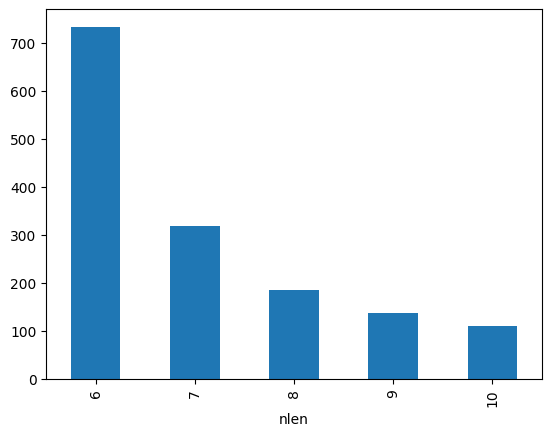

In [196]:
references['nlen'].value_counts().plot.bar();

In [197]:
bible.iloc[references[references.eval('nlen - olen') != 0]['ostart']][['book', 'chapter', 'verse']]

,book,chapter,verse
106185,5,6,5
106186,5,6,5
106188,5,6,5
106189,5,6,5
104782,5,4,29
109429,5,11,13
118288,5,26,16
121317,5,30,2
137037,6,22,5
137039,6,22,5


In [198]:
bible.iloc[references[references.eval('nlen - olen') != 0]['nstart']][['book', 'chapter', 'verse']]

,book,chapter,verse
26436,41,12,30
26436,41,12,30
26436,41,12,30
26436,41,12,30
26438,41,12,30
26438,41,12,30
26438,41,12,30
26438,41,12,30
26442,41,12,30
26442,41,12,30


In [199]:
bible_books = [
    "Genesis",
    "Exodus",
    "Leviticus",
    "Numbers",
    "Deuteronomy",
    "Joshua",
    "Judges",
    "Ruth",
    "1 Samuel",
    "2 Samuel",
    "1 Kings",
    "2 Kings",
    "1 Chronicles",
    "2 Chronicles",
    "Ezra",
    "Nehemiah",
    "Esther",
    "Job",
    "Psalms",
    "Proverbs",
    "Ecclesiastes",
    "Song of Solomon",
    "Isaiah",
    "Jeremiah",
    "Lamentations",
    "Ezekiel",
    "Daniel",
    "Hosea",
    "Joel",
    "Amos",
    "Obadiah",
    "Jonah",
    "Micah",
    "Nahum",
    "Habakkuk",
    "Zephaniah",
    "Haggai",
    "Zechariah",
    "Malachi",
    "Matthew",
    "Mark",
    "Luke",
    "John",
    "Acts",
    "Romans",
    "1 Corinthians",
    "2 Corinthians",
    "Galatians",
    "Ephesians",
    "Philippians",
    "Colossians",
    "1 Thessalonians",
    "2 Thessalonians",
    "1 Timothy",
    "2 Timothy",
    "Titus",
    "Philemon",
    "Hebrews",
    "James",
    "1 Peter",
    "2 Peter",
    "1 John",
    "2 John",
    "3 John",
    "Jude",
    "Revelation",
]
bible_books = pd.Series(bible_books)

In [200]:
bible_books[:3]

0      Genesis
1       Exodus
2    Leviticus
dtype: object

In [201]:
bible_tuple = bible[["verse","chapter","book"]]
verse_dict = pd.Series(zip(bible_books.loc[bible_tuple['book']-1], bible_tuple['chapter'], bible_tuple['verse']))

In [202]:
references['nstart']

0       475406
1       475750
2       475750
3       475750
4       475750
         ...  
1479    612866
1480    612866
1481    612901
1482    612901
1483    612901
Name: nstart, Length: 1484, dtype: int64

In [203]:
verse_dict.iloc[references['nend']].index.duplicated().any()


True

In [204]:
references2 = pd.DataFrame(index = references.index)
references2['n_start'] = verse_dict.iloc[references['nstart']].reset_index(drop=True)
references2['n_end'] = verse_dict.iloc[references['nend']].reset_index(drop=True)
references2['o_start'] = verse_dict.iloc[references['ostart']].reset_index(drop=True)
references2['o_end'] = verse_dict.iloc[references['oend']].reset_index(drop=True)

In [205]:
references2

,n_start,n_end,o_start,o_end
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)"
1,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 16, 11)","(Genesis, 16, 11)"
2,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 17, 19)","(Genesis, 17, 19)"
3,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 37)","(Genesis, 19, 37)"
4,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 38)","(Genesis, 19, 38)"
...,...,...,...,...
1479,"(Revelation, 22, 18)","(Revelation, 22, 19)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)"
1480,"(Revelation, 22, 18)","(Revelation, 22, 19)","(Jeremiah, 25, 13)","(Jeremiah, 25, 15)"
1481,"(Revelation, 22, 19)","(Revelation, 22, 20)","(Deuteronomy, 28, 58)","(Deuteronomy, 28, 58)"
1482,"(Revelation, 22, 19)","(Revelation, 22, 20)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)"


In [206]:
import plotly.express as px

In [207]:
(references2['n_start']).str[0]

0          Matthew
1          Matthew
2          Matthew
3          Matthew
4          Matthew
           ...    
1479    Revelation
1480    Revelation
1481    Revelation
1482    Revelation
1483    Revelation
Name: n_start, Length: 1484, dtype: object

In [208]:
book_authors = {
    "Genesis": "Moses",
    "Exodus": "Moses",
    "Leviticus": "Moses",
    "Numbers": "Moses",
    "Deuteronomy": "Moses",
    "Joshua": "Joshua",
    "Judges": "Samuel; Nathan; Gad",
    "Ruth": "Samuel",
    "1 Samuel": "Samuel; Nathan; Gad",
    "2 Samuel": "Gad; Nathan",
    "1 Kings": "Jeremiah",
    "2 Kings": "Jeremiah",
    "1 Chronicles": "Ezra",
    "2 Chronicles": "Ezra",
    "Ezra": "Ezra",
    "Nehemiah": "Nehemiah",
    "Esther": "Mordecai",
    "Job": "Unknown",
    "Psalms": "David and others",
    "Proverbs": "Solomon; Agur; Lemuel",
    "Ecclesiastes": "Solomon",
    "Song of Songs": "Solomon",
    "Isaiah": "Isaiah",
    "Jeremiah": "Jeremiah",
    "Lamentations": "Jeremiah",
    "Ezekiel": "Ezekiel",
    "Daniel": "Daniel",
    "Hosea": "Hosea",
    "Joel": "Joel",
    "Amos": "Amos",
    "Obadiah": "Obadiah",
    "Jonah": "Jonah",
    "Micah": "Micah",
    "Nahum": "Nahum",
    "Habakkuk": "Habakkuk",
    "Zephaniah": "Zephaniah",
    "Haggai": "Haggai",
    "Zechariah": "Zechariah",
    "Malachi": "Malachi",
    "Matthew": "Matthew",
    "Mark": "Mark",
    "Luke": "Luke",
    "John": "John",
    "Acts": "Luke",
    "Romans": "Paul",
    "1 Corinthians": "Paul",
    "2 Corinthians": "Paul",
    "Galatians": "Paul",
    "Ephesians": "Paul",
    "Philippians": "Paul",
    "Colossians": "Paul",
    "1 Thessalonians": "Paul",
    "2 Thessalonians": "Paul",
    "1 Timothy": "Paul",
    "2 Timothy": "Paul",
    "Titus": "Paul",
    "Philemon": "Paul",
    "Hebrews": "Unknown",
    "James": "James",
    "1 Peter": "Peter",
    "2 Peter": "Peter",
    "1 John": "John",
    "2 John": "John",
    "3 John": "John",
    "Jude": "Jude",
    "Revelation": "John"
}


In [209]:
px.histogram(
    x = references2['n_start'].str[0],
    labels={'x': 'Book of the Bible'}
)

In [210]:
px.histogram(
    x = references2['n_start'].str[0].map(book_authors),
    labels = {'x': 'Authors'}
)

#### Most quoted verse in the Bible: 
1. "Love the Lord your God with all your heart and with all your soul and with all your mind and with all your strength.’"
2. "“The virgin will conceive and give birth to a son, and they will call him Immanuel”[a] (which means “God with us”)"
3. "He answered, “‘Love the Lord your God with all your heart and with all your soul and with all your strength and with all your mind’; and, ‘Love your neighbor as yourself."
4. "He answered, “‘Love the Lord your God with all your heart and with all your soul and with all your strength and with all your mind’; and, ‘Love your neighbor as yourself."


In [211]:
entire_allusions = (references2['n_start'] + references2['n_end']).value_counts().to_frame()

In [212]:
entire_allusions.index = pd.Series(entire_allusions.index).apply(lambda x : x[0] +":"+  str(x[1])+":"+str(x[-1]))

### Saving References in a useful format to a pickle.

#### Saving the bible with tuple index

In [213]:
bible['book'] = bible_books.loc[bible['book'] -1].values
bible.index = pd.Series(zip(bible['book'], bible['chapter'], bible['verse']))
bible.index = pd.MultiIndex.from_tuples(bible.index, names=['book', 'chapter', 'verse'])
with open("./pickles/bible.pickle", "wb") as f:
    pickle.dump(bible, f)
bible

text   str  verse  chapter        book      rmac
book       chapter verse                                                      
Genesis    1       1            εν  1722      1        1     Genesis      prep
                   1          αρχη   746      1        1     Genesis     n-dsf
                   1      εποιησεν  4160      1        1     Genesis  v-aai-3s
                   1             ο  3588      1        1     Genesis     t-nsm
                   1          θεος  2316      1        1     Genesis     n-nsm
...                            ...   ...    ...      ...         ...       ...
Revelation 22      21          τοῦ  3588     21       22  Revelation     t-gsm
                   21       κυρίου  2962     21       22  Revelation     n-gsm
                   21        ἰησοῦ  2424     21       22  Revelation     n-gsm
                   21         μετὰ  3326     21       22  Revelation      prep
                   21       πάντων  3956     21       22  Revelation     a-gpm

[612925 rows x 6 columns]

In [214]:
bible.loc[("Genesis", 1)].head(3)

/tmp/ipykernel_12708/3741901978.py:1: PerformanceWarning:

indexing past lexsort depth may impact performance.



,text,str,verse,chapter,book,rmac
verse,,,,,,
1,εν,1722,1,1,Genesis,prep
1,αρχη,746,1,1,Genesis,n-dsf
1,εποιησεν,4160,1,1,Genesis,v-aai-3s


#### Saving references2

In [215]:
" ".join(bible.loc[('Genesis', 1, 1)]['text'].values)

/tmp/ipykernel_12708/3086043418.py:1: PerformanceWarning:

indexing past lexsort depth may impact performance.



'εν αρχη εποιησεν ο θεος τον ουρανον και την γην'

In [216]:
bible

text   str  verse  chapter        book      rmac
book       chapter verse                                                      
Genesis    1       1            εν  1722      1        1     Genesis      prep
                   1          αρχη   746      1        1     Genesis     n-dsf
                   1      εποιησεν  4160      1        1     Genesis  v-aai-3s
                   1             ο  3588      1        1     Genesis     t-nsm
                   1          θεος  2316      1        1     Genesis     n-nsm
...                            ...   ...    ...      ...         ...       ...
Revelation 22      21          τοῦ  3588     21       22  Revelation     t-gsm
                   21       κυρίου  2962     21       22  Revelation     n-gsm
                   21        ἰησοῦ  2424     21       22  Revelation     n-gsm
                   21         μετὰ  3326     21       22  Revelation      prep
                   21       πάντων  3956     21       22  Revelation     a-gpm

[612925 rows x 6 columns]

In [217]:
bible_by_verse = bible.groupby(level=[0,1,2], sort=False)['text'].agg(lambda x : " ".join(x))

In [218]:
references2['n_text_start'] = bible_by_verse.loc[references2['n_start']].values
references2['n_text_end'] = bible_by_verse.loc[references2['n_end']].values
references2['o_text_start'] = bible_by_verse.loc[references2['o_start']].values
references2['o_text_end'] = bible_by_verse.loc[references2['o_end']].values

In [219]:
references2

,n_start,n_end,o_start,o_end,n_text_start,n_text_end,o_text_start,o_text_end
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)",βίβλος γενέσεως ἰησοῦ χριστοῦ υἱοῦ δαυεὶδ υἱοῦ...,ἀβραὰμ ἐγέννησεν τὸν ἰσαάκ ἰσαὰκ δὲ ἐγέννησεν ...,και αυται αι γενεσεις ισαακ του υιου αβρααμ αβ...,ην δε ισαακ ετων τεσσαρακοντα οτε ελαβεν την ρ...
1,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 16, 11)","(Genesis, 16, 11)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,και ειπεν αυτη ο αγγελος κυριου ιδου συ εν γασ...,και ειπεν αυτη ο αγγελος κυριου ιδου συ εν γασ...
2,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 17, 19)","(Genesis, 17, 19)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,ειπεν δε ο θεος τω αβρααμ ναι ιδου σαρρα η γυν...,ειπεν δε ο θεος τω αβρααμ ναι ιδου σαρρα η γυν...
3,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 37)","(Genesis, 19, 37)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,και ετεκεν η πρεσβυτερα υιον και εκαλεσεν το ο...,και ετεκεν η πρεσβυτερα υιον και εκαλεσεν το ο...
4,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 38)","(Genesis, 19, 38)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,ετεκεν δε και η νεωτερα υιον και εκαλεσεν το ο...,ετεκεν δε και η νεωτερα υιον και εκαλεσεν το ο...
...,...,...,...,...,...,...,...,...
1479,"(Revelation, 22, 18)","(Revelation, 22, 19)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)",μαρτυρῶ ἐγὼ παντὶ τῷ ἀκούοντι τοὺς λόγους τῆς ...,καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,πορευθητε ζητησατε τον κυριον περι εμου και πε...,και επορευθη χελκιας και οις ειπεν ο βασιλευς ...
1480,"(Revelation, 22, 18)","(Revelation, 22, 19)","(Jeremiah, 25, 13)","(Jeremiah, 25, 15)",μαρτυρῶ ἐγὼ παντὶ τῷ ἀκούοντι τοὺς λόγους τῆς ...,καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,και επαξω επι την γην εκεινην παντας τους λογο...,οσα επροφητευσεν ιερεμιας επι παντα τα εθνη ου...
1481,"(Revelation, 22, 19)","(Revelation, 22, 20)","(Deuteronomy, 28, 58)","(Deuteronomy, 28, 58)",καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,λέγει ὁ μαρτυρῶν ταῦτα ναί ἔρχομαι ταχύ ἀμήν ἔ...,εαν μη εισακουσητε ποιειν παντα τα ρηματα του ...,εαν μη εισακουσητε ποιειν παντα τα ρηματα του ...
1482,"(Revelation, 22, 19)","(Revelation, 22, 20)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)",καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,λέγει ὁ μαρτυρῶν ταῦτα ναί ἔρχομαι ταχύ ἀμήν ἔ...,πορευθητε ζητησατε τον κυριον περι εμου και πε...,και επορευθη χελκιας και οις ειπεν ο βασιλευς ...


In [227]:
references2['new_text'] = np.where(
    references2['n_text_start'] == references2['n_text_end'],
    references2['n_text_start'], # True
    references2['n_text_start'] + references2['n_text_end'], # False
)
references2['old_text'] = np.where(
    references2['o_text_start'] == references2['o_text_end'],
    references2['o_text_start'], # True
    references2['o_text_start'] + references2['o_text_end'], # False
)
references2 = references2.drop(['n_text_start', 'n_text_end', 'o_text_start', 'o_text_end'], axis=1)

In [228]:
references2.head(5)

,n_start,n_end,o_start,o_end,new_text,old_text
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)",βίβλος γενέσεως ἰησοῦ χριστοῦ υἱοῦ δαυεὶδ υἱοῦ...,και αυται αι γενεσεις ισαακ του υιου αβρααμ αβ...
1,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 16, 11)","(Genesis, 16, 11)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,και ειπεν αυτη ο αγγελος κυριου ιδου συ εν γασ...
2,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 17, 19)","(Genesis, 17, 19)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,ειπεν δε ο θεος τω αβρααμ ναι ιδου σαρρα η γυν...
3,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 37)","(Genesis, 19, 37)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,και ετεκεν η πρεσβυτερα υιον και εκαλεσεν το ο...
4,"(Matthew, 1, 21)","(Matthew, 1, 21)","(Genesis, 19, 38)","(Genesis, 19, 38)",τέξεται δὲ υἱὸν καὶ καλέσεις τὸ ὄνομα αὐτοῦ ἰη...,ετεκεν δε και η νεωτερα υιον και εκαλεσεν το ο...
